## Vallius, Shi, Novikov et al. 2026

### Fig 8D immune annotations in entropy regions (high vs low)

In [1]:
import sys
import os
import anndata as ad
import pandas as pd
import scanpy as sc
import re
import numpy as np
import seaborn as sns; sns.set(color_codes=True)
import scimap as sm  
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import pearsonr
import napari

Running SCIMAP  2.1.0


In [2]:
df = pd.read_csv(r"C:\Users\tav9\HMS Dropbox\Tuulia Vallius\2024-Vallius-Novikov-Shi-Melanoma_PCA\supplementary materials\CyCIF_data_for_plotting\Fig8D.csv")

In [3]:
df

,Unnamed: 0,ROI,entropy,immune response
0,0,'LSP13135_026',high,brisk
1,1,'LSP13140_001',high,non-brisk
2,2,'LSP13140_038',high,non-brisk
3,3,'LSP13140_043',high,non-brisk
4,4,'LSP13145_059',high,brisk
5,5,'LSP13150_002',high,no immune
6,6,'LSP13150_004',high,brisk
7,7,'LSP13150_018',high,no immune
8,8,'LSP13155_024',high,no immune
9,9,'LSP13155_025',high,no immune



Proportions DataFrame after reordering annotations and x-axis:
immune response  no immune  non-brisk  brisk
entropy                                     
low                   0.65       0.25   0.10
high                  0.35       0.50   0.15


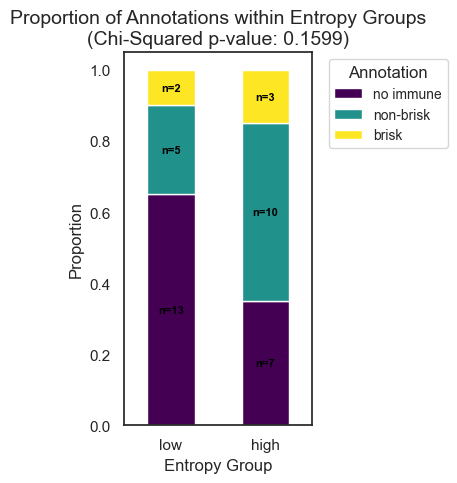

In [5]:
from scipy.stats import chi2_contingency

# --- Statistical Test: Chi-Squared Test of Independence ---
contingency_table = pd.crosstab(df['entropy'], df['immune response'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# Calculate raw counts for N= labels
counts = contingency_table

# Calculate proportions (for bar heights)
proportions = counts.div(counts.sum(axis=1), axis=0)

# --- Reorder the annotations (stacked segments) ---
desired_annotation_order = ['no immune', 'non-brisk', 'brisk']

proportions = proportions.reindex(columns=desired_annotation_order, fill_value=0)
counts = counts.reindex(columns=desired_annotation_order, fill_value=0)

# --- Reorder the x-axis (entropy groups) ---
# Set your desired entropy order here:
desired_entropy_order = ['low', 'high']

# Keep only groups that exist, and reorder them
proportions = proportions.reindex(index=desired_entropy_order).dropna(how='all')
counts = counts.reindex(index=desired_entropy_order).dropna(how='all')

print("\nProportions DataFrame after reordering annotations and x-axis:")
print(proportions)

# --- Plotting with N= labels and P-value ---

fig, ax = plt.subplots(figsize=(5, 5))

# Plot the reordered proportions
bar_containers = proportions.plot(kind='bar', stacked=True, ax=ax, cmap='viridis')

ax.set_title(
    f'Proportion of Annotations within Entropy Groups\n(Chi-Squared p-value: {p_value:.4f})',
    fontsize=14
)
ax.set_xlabel('Entropy Group', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Annotation', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Add N= labels
for container, annotation_type in zip(ax.containers, proportions.columns):
    for i, patch in enumerate(container.patches):
        height = patch.get_height()
        width = patch.get_width()
        x = patch.get_x()
        y = patch.get_y()

        entropy_group = proportions.index[i]
        raw_count = counts.loc[entropy_group, annotation_type]

        if height > 0 and raw_count > 0:
            ax.text(
                x + width / 2,
                y + height / 2,
                f'n={raw_count}',
                ha='center',
                va='center',
                color='black',
                fontsize=8,
                weight='bold'
            )

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig("C:/Users/tav9/Dropbox (HMS)/test/test/immune_annotations_entropy_geomx_ROIs.pdf")
plt.show()